<a href="https://colab.research.google.com/github/mahdieslaminet/Machine_Vision_Colab_Based/blob/master/12-Trackbar-in-OpenCV-with-highgui.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">افزودن Trackbar در OpenCV</div>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


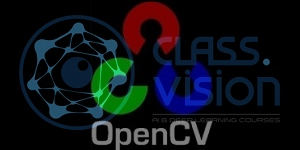

In [3]:
import cv2
from google.colab import drive
from google.colab.patches import cv2_imshow
import os

# اتصال به گوگل درایو
drive.mount('/content/drive')

# حداکثر مقدار اسلایدر
alpha_slider_max = 100

# مسیر فایل‌ها
image_src1_path = '/content/drive/My Drive/images/class.vision.jpg'
image_src2_path = '/content/drive/My Drive/images/opencv.jpg'

# خواندن تصاویر
src1 = cv2.imread(image_src1_path)
src2 = cv2.imread(image_src2_path)

# بررسی اینکه تصاویر با موفقیت بارگذاری شده‌اند
if src1 is None or src2 is None:
    print("یکی از تصاویر بارگذاری نشد. لطفاً مسیرها را بررسی کنید.")
else:
    def blend_images(val):
        alpha = val / alpha_slider_max
        beta = 1.0 - alpha
        blended = cv2.addWeighted(src1, alpha, src2, beta, 0.0)
        cv2_imshow(blended)

    # اجرای ترکیب اولیه
    blend_images(50)  # مقدار اولیه: 50٪ از هر تصویر


<div style="direction:rtl;text-align:right;font-family:Tahoma">
افزودن ثبت نتیجه در notebook</div>

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
from google.colab.patches import cv2_imshow

# مسیر تصاویر (قبل از این مرحله باید فایل‌ها در دسترس باشند)
image_src1_path = '/content/drive/My Drive/images/class.vision.jpg'
image_src2_path = '/content/drive/My Drive/images/opencv.jpg'

# خواندن تصاویر
src1 = cv2.imread(image_src1_path)
src2 = cv2.imread(image_src2_path)

# بررسی اینکه تصاویر بارگذاری شده‌اند
if src1 is None or src2 is None:
    print("خطا در بارگذاری تصاویر")
else:
    # تغییر اندازه در صورت نابرابری ابعاد
    if src1.shape != src2.shape:
        src2 = cv2.resize(src2, (src1.shape[1], src1.shape[0]))

    # تابع برای ترکیب و نمایش
    def blend_images(alpha_val):
        alpha = alpha_val / 100
        beta = 1.0 - alpha
        blended = cv2.addWeighted(src1, alpha, src2, beta, 0.0)
        cv2_imshow(blended)
        print(f"alpha: {alpha:.2f}")

    # اسلایدر تعاملی
    interact(blend_images, alpha_val=IntSlider(min=0, max=100, step=1, value=50, description='Alpha'))


interactive(children=(IntSlider(value=50, description='Alpha'), Output()), _dom_classes=('widget-interact',))

<div style="direction:rtl;text-align:right;font-family:Tahoma">
افزودن trackbar برای تغییر رنگ صفحه</div>

In [8]:
import numpy as np
import cv2
from ipywidgets import interact, IntSlider, ToggleButton, VBox
from matplotlib import pyplot as plt

def update(r=0, g=0, b=0, switch=False):
    img = np.zeros((300, 512, 3), dtype=np.uint8)
    if switch:
        img[:] = [b, g, r]
    else:
        img[:] = 0
    plt.imshow(img[..., ::-1])  # BGR to RGB
    plt.axis('off')
    plt.show()

interact(update,
         r=IntSlider(min=0, max=255, step=1, value=0, description='R'),
         g=IntSlider(min=0, max=255, step=1, value=0, description='G'),
         b=IntSlider(min=0, max=255, step=1, value=0, description='B'),
         switch=ToggleButton(value=False, description='ON/OFF'))


interactive(children=(IntSlider(value=0, description='R', max=255), IntSlider(value=0, description='G', max=25…

<function __main__.update(r=0, g=0, b=0, switch=False)>

https://docs.opencv.org/3.4/da/d6a/tutorial_trackbar.html

https://docs.opencv.org/4.x/d9/dc8/tutorial_py_trackbar.html